In [121]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
from PIL import Image

In [122]:
import numpy as np

bayer_0 = np.array([[1,1,1,1],
                    [1,1,1,1],
                    [1,1,1,1],
                    [1,1,1,1]])

bayer_1 = np.array([[0,1,1,1],
                    [1,1,1,1],
                    [1,1,1,1],
                    [1,1,1,1]])

bayer_2 = np.array([[0,1,1,1],
                    [1,1,1,1],
                    [1,1,0,1],
                    [1,1,1,1]])

bayer_3 = np.array([[0,1,0,1],
                    [1,1,1,1],
                    [1,1,0,1],
                    [1,1,1,1]])

bayer_4 = np.array([[0,1,0,1],
                    [1,1,1,1],
                    [0,1,0,1],
                    [1,1,1,1]])

bayer_5 = np.array([[0,1,0,1],
                    [1,0,1,1],
                    [0,1,0,1],
                    [1,1,1,1]])

bayer_6 = np.array([[0,1,0,1],
                    [1,0,1,1],
                    [0,1,0,1],
                    [1,1,1,0]])

bayer_7 = np.array([[0,1,0,1],
                    [1,0,1,0],
                    [0,1,0,1],
                    [1,1,1,0]])

bayer_8 = np.array([[0,1,0,1],
                    [1,0,1,0],
                    [0,1,0,1],
                    [1,0,1,0]])

bayer_9 = np.array([[0,0,0,1],
                    [1,0,1,0],
                    [0,1,0,1],
                    [1,0,1,0]])

bayer_10 = np.array([[0,0,0,1],
                     [1,0,1,0], 
                     [0,1,0,0],
                     [1,0,1,0]])

bayer_11 = np.array([[0,0,0,0],
                     [1,0,1,0], 
                     [0,1,0,0],
                     [1,0,1,0]])

bayer_12 = np.array([[0,0,0,0],
                     [1,0,1,0], 
                     [0,0,0,0],
                     [1,0,1,0]])

bayer_13 = np.array([[0,0,0,0],
                     [0,0,1,0], 
                     [0,0,0,0],
                     [1,0,1,0]])

bayer_14 = np.array([[0,0,0,0],
                     [0,0,1,0], 
                     [0,0,0,0],
                     [1,0,0,0]])


bayer_15 = np.array([[0,0,0,0],
                     [0,0,0,0], 
                     [0,0,0,0],
                     [1,0,0,0]])

bayer_16 = np.array([[0,0,0,0],
                     [0,0,0,0], 
                     [0,0,0,0],
                     [0,0,0,0]])

bayer_matrices = [bayer_0, bayer_1, bayer_2, bayer_3, bayer_4, bayer_5, bayer_6, bayer_7, bayer_8, bayer_9, bayer_10, bayer_11, bayer_12, bayer_13, bayer_14, bayer_15, bayer_16]
bayer_matrices = bayer_matrices[::-1]





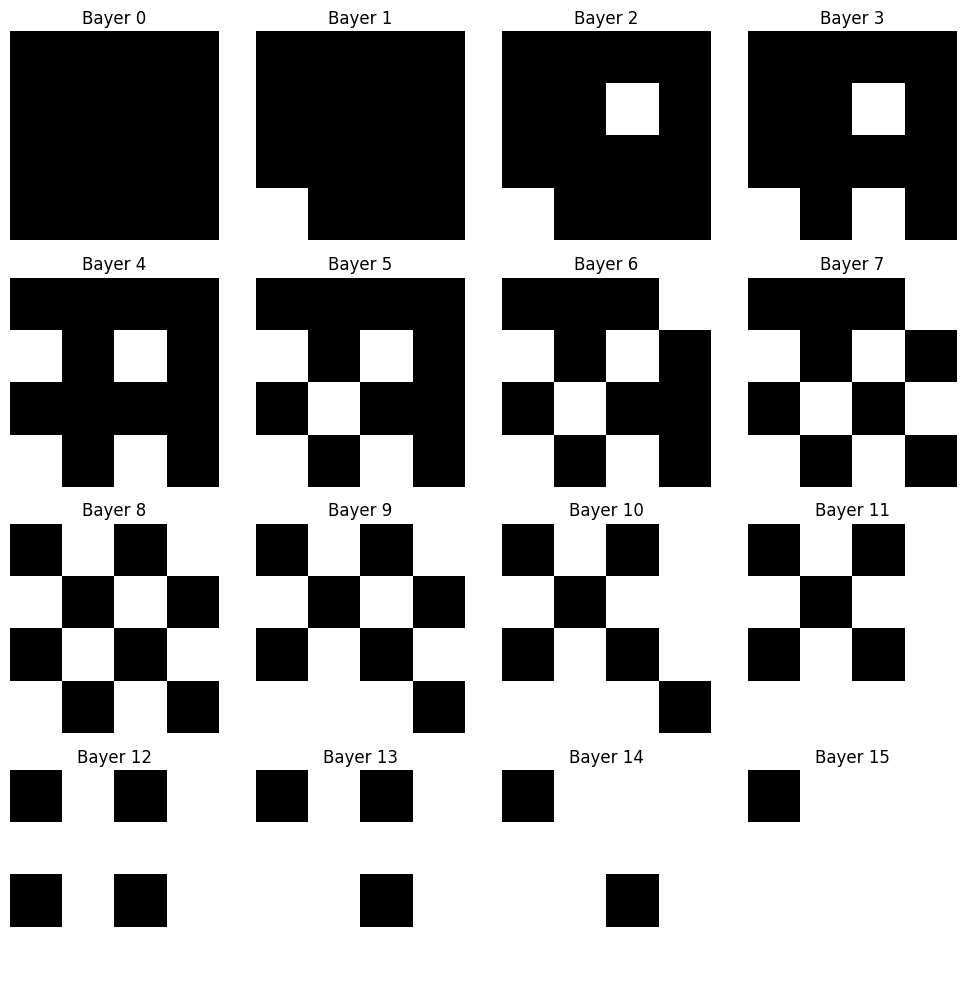

In [123]:
#Plotting the bayer matrices
import matplotlib.pyplot as plt
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(bayer_matrices[i], cmap='gray', vmin=0, vmax=1)
    ax.set_title(f'Bayer {i}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [124]:
def get_bayer(pix):
    num = int((pix/(255+1)) * 17)
    return bayer_matrices[num]

In [125]:
img = cv.imread("swiss.jpg",1)
img = cv.cvtColor(img,cv.COLOR_BGR2GRAY)
img = img[0:1220,:]
img.shape

(1220, 800)

In [126]:
new = np.zeros((img.shape[0]*4,img.shape[1]*4),dtype=np.uint8)

for i in range(int(img.shape[0])):
    for j in range(int(img.shape[1])):
        x=4*i
        y = 4*j
        new[x:x+4,y:y+4] = get_bayer(img[i,j])

In [127]:
cv.imwrite("bayer_4x4_swiss.jpg",new*255)

True